# 04 · Discounts, losses and dispatch time

Actual Superstore sample data, not simulated outputs. Run cells from top to bottom. Dollar amounts are USD.


In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/project.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the extracted project folder.')
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.project import load, summarize, save_table, chart
pd.set_option('display.max_columns',30)
pd.set_option('display.width',160)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize':(10,5),'axes.spines.top':False,'axes.spines.right':False})

          Lines     Sales    Profit  Mean_Line_Profit  Loss_Rate  Margin_pct
Discount                                                                    
0.00         72  71578.76  13276.30            184.39       0.00       18.55
0.20         71  45430.23   -303.56             -4.28       0.44       -0.67
0.30         54  25182.15  -3402.33            -63.01       0.93      -13.51
0.40         75  45614.41 -16187.40           -215.83       1.00      -35.49
0.45         11   5484.97  -2493.11           -226.65       1.00      -45.45
0.50         36  13675.01  -8615.39           -239.32       1.00      -63.00
Tables above 20% discount:
           Profit
count   176.00000
min   -1862.31240
max      41.93400
mean   -174.42172


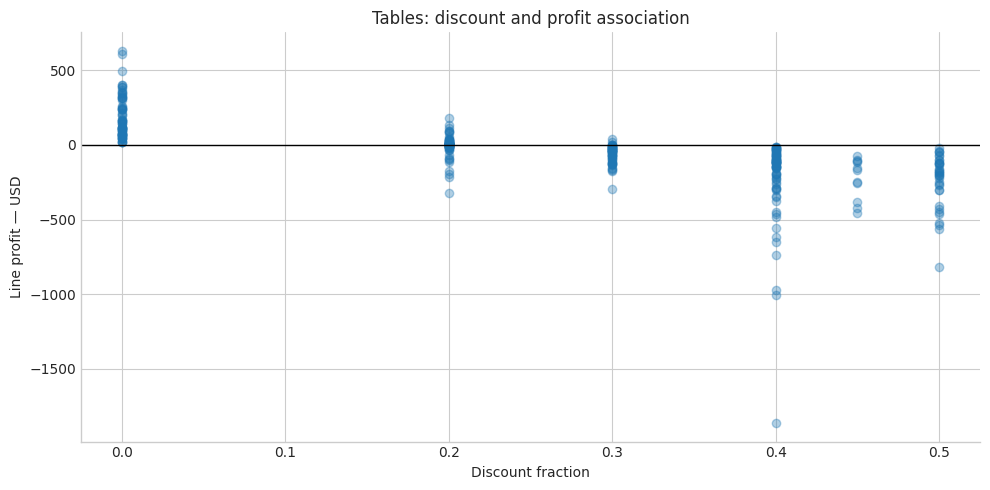

In [2]:
df=load()
discounts=df.groupby(['Sub-Category','Discount'],observed=True).agg(Lines=('Row ID','count'),Sales=('Sales','sum'),Profit=('Profit','sum'),Mean_Line_Profit=('Profit','mean'),Loss_Rate=('Loss Flag','mean'))
discounts['Margin_pct']=100*discounts.Profit/discounts.Sales
print(discounts.loc['Tables'].round(2));save_table(discounts,'discount_analysis')
tables=df[df['Sub-Category']=='Tables']
plt.scatter(tables.Discount,tables.Profit,alpha=.35);plt.axhline(0,color='black',linewidth=1)
plt.xlabel('Discount fraction');plt.ylabel('Line profit — USD');plt.title('Tables: discount and profit association');chart('tables_discounts')
print('Tables above 20% discount:')
print(tables[tables.Discount>0.2].agg({'Profit':['count','min','max','mean']}))

## Scenario, not a causal estimate
For Tables and Bookcases with discounts above 20%, reconstruct assumed pre-discount sales as Sales/(1−Discount), then apply a 20% cap. Assume constant quantity, unchanged unit costs, unchanged product mix and no customer response. Under these assumptions, extra sales equal extra profit. This is a mechanical full-period scenario, NOT annual recovered profit or a forecast. Discounts may be associated with different products, regions and order sizes.

In [3]:
mask=df['Sub-Category'].isin(['Tables','Bookcases']) & df.Discount.gt(.20)
scenario=df.loc[mask,['Row ID','Sub-Category','Sales','Profit','Discount']].copy()
scenario['Assumed_List_Sales']=scenario.Sales/(1-scenario.Discount)
scenario['Scenario_Sales']=scenario.Assumed_List_Sales*.8
scenario['Mechanical_Uplift']=scenario.Scenario_Sales-scenario.Sales
scenario['Scenario_Profit']=scenario.Profit+scenario.Mechanical_Uplift
print(scenario[['Sales','Profit','Scenario_Sales','Scenario_Profit','Mechanical_Uplift']].sum().round(2))
save_table(scenario,'discount_scenario')
ship=df.groupby(['Order ID','Ship Mode'],as_index=False)['Ship Days'].max()
shipping=ship.groupby('Ship Mode')['Ship Days'].agg(['count','mean','median','max'])
print(shipping.round(2));save_table(shipping,'dispatch_time')

Sales                118500.54
Profit               -41795.98
Scenario_Sales       159654.50
Scenario_Profit        -642.03
Mechanical_Uplift     41153.96
dtype: float64
                count  mean  median  max
Ship Mode                               
First Class       787  2.19     2.0    4
Same Day          264  0.05     0.0    1
Second Class      964  3.23     3.0    5
Standard Class   2994  5.00     5.0    7


## Recommended next action
Audit deeply discounted loss-making lines and test any pricing change in a controlled pilot. Validate conversion, quantity, contribution margin and customer response. The dataset supports dispatch-time summaries, not delivery SLAs or causal shipping-cost explanations.